In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matlab.engine


In [16]:
nt = 2048


dt = 0.5
Fs = 1/dt
t = np.arange(nt)*dt

# x = np.random.randn(nt)
x = np.cos(2*np.pi*0.03*t)

In [6]:
eng = matlab.engine.start_matlab()

In [20]:
# Convert numpy array to MATLAB column vector
x_mat = matlab.double(x.astype(float).reshape(-1, 1).tolist())

eng.workspace["x"] = x_mat
eng.workspace["Fs"] = float(Fs)

eng.eval(
"""
[cfs,f,coi] = cwt(x,Fs,...
    'TimeBandwidth',10, ...
    'FrequencyLimits', [0.007, 0.1]);

amp = abs(cfs);
""",
nargout=0)

amp = np.array(eng.workspace["amp"])
freq = np.array(eng.workspace["f"]).squeeze()
coi  = np.array(eng.workspace["coi"]).squeeze()

print(amp.shape)

(39, 2048)


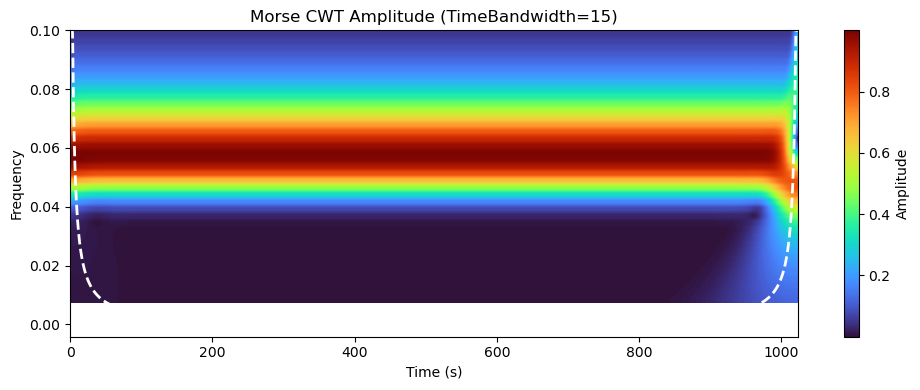

In [24]:
fig, ax = plt.subplots(figsize=(10,4))

extent = [
    0,
    t.max(),
    freq.min(),
    freq.max()
]

im = ax.imshow(
    amp[::-1],
    aspect="auto",
    origin="lower",
    extent=extent,
    cmap="turbo"
)

# COI overlay
ax.plot(
    t,
    coi,
    "w--",
    lw=2,
)

ax.set_ylabel("Frequency")
ax.set_xlabel("Time (s)")
ax.set_title("Morse CWT Amplitude (TimeBandwidth=15)")

plt.colorbar(im, ax=ax, label="Amplitude")


plt.tight_layout()
plt.show()